<a href="https://colab.research.google.com/github/adityaaaa342/Pattern-Recognition-/blob/main/practical_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [5]:
emails = [
    "Congratulations! You won a free iPhone.",
    "Win cash prize now.",
    "Claim your lottery reward.",
    "Free gift waiting for you.",
    "Limited time offer buy now.",
    "Meeting scheduled tomorrow.",
    "Project report submission today.",
    "Please review the document.",
    "Team meeting at 4 PM.",
    "Invoice attached for your purchase.",
    "Click here to win money.",
    "Urgent! Update your account.",
    "Exclusive discount available.",
    "Congratulations you won lottery.",
    "Meeting postponed until Monday.",
    "Client meeting tomorrow morning.",
    "Please send project files.",
    "Lunch with team today.",
    "Reminder for project review.",
    "Schedule discussion with client."
]

labels = [
    "Spam","Spam","Spam","Spam","Spam",
    "Ham","Ham","Ham","Ham","Ham",
    "Spam","Spam","Spam","Spam",
    "Ham","Ham","Ham","Ham","Ham","Ham"
]

df = pd.DataFrame({
    "Email": emails,
    "Label": labels
})

print("\nDataset")
print(df)



Dataset
                                      Email Label
0   Congratulations! You won a free iPhone.  Spam
1                       Win cash prize now.  Spam
2                Claim your lottery reward.  Spam
3                Free gift waiting for you.  Spam
4               Limited time offer buy now.  Spam
5               Meeting scheduled tomorrow.   Ham
6          Project report submission today.   Ham
7               Please review the document.   Ham
8                     Team meeting at 4 PM.   Ham
9       Invoice attached for your purchase.   Ham
10                 Click here to win money.  Spam
11             Urgent! Update your account.  Spam
12            Exclusive discount available.  Spam
13         Congratulations you won lottery.  Spam
14          Meeting postponed until Monday.   Ham
15         Client meeting tomorrow morning.   Ham
16               Please send project files.   Ham
17                   Lunch with team today.   Ham
18             Reminder for project revie

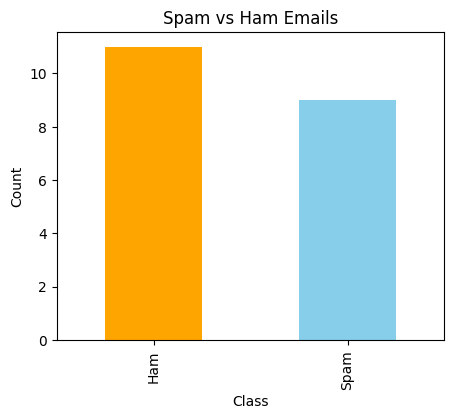

In [6]:
plt.figure(figsize=(5,4))
df["Label"].value_counts().plot(kind="bar", color=["orange","skyblue"])
plt.title("Spam vs Ham Emails")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


In [7]:
vectorizer = CountVectorizer(stop_words='english')

X = vectorizer.fit_transform(df["Email"])
y = df["Label"]


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [9]:

model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [10]:
y_pred = model.predict(X_test)

print("\nAccuracy =", accuracy_score(y_test, y_pred))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))


Accuracy = 1.0

Classification Report

              precision    recall  f1-score   support

         Ham       1.00      1.00      1.00         4
        Spam       1.00      1.00      1.00         2

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



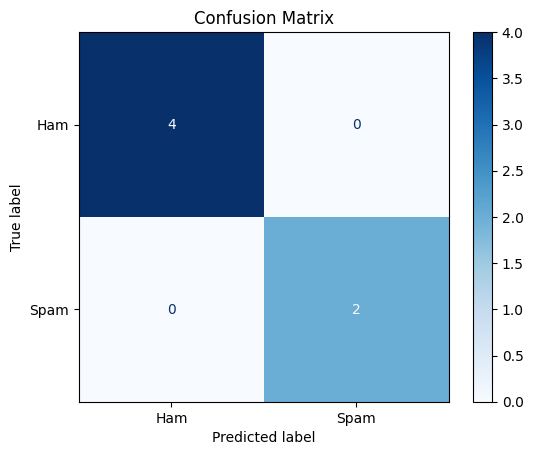

In [11]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


In [12]:
feature_names = vectorizer.get_feature_names_out()

spam_index = list(model.classes_).index("Spam")
ham_index = list(model.classes_).index("Ham")

spam_scores = model.feature_log_prob_[spam_index]
ham_scores = model.feature_log_prob_[ham_index]

spam_difference = spam_scores - ham_scores
ham_difference = ham_scores - spam_scores

spam_df = pd.DataFrame({
    "Word": feature_names,
    "Score": spam_difference
}).sort_values("Score", ascending=False)

ham_df = pd.DataFrame({
    "Word": feature_names,
    "Score": ham_difference
}).sort_values("Score", ascending=False)

print("\nTop Spam Words")
print(spam_df.head(10))

print("\nTop Ham Words")
print(ham_df.head(10))


Top Spam Words
         Word     Score
19    lottery  1.084224
0     account  0.678758
3         buy  0.678758
2   available  0.678758
6       click  0.678758
14       free  0.678758
9    discount  0.678758
5       claim  0.678758
15       gift  0.678758
12  exclusive  0.678758

Top Ham Words
          Word     Score
29     project  1.400683
33      review  1.113001
1     attached  0.707536
7       client  0.707536
13       files  0.707536
41       today  0.707536
10  discussion  0.707536
11    document  0.707536
21     meeting  0.707536
27   postponed  0.707536


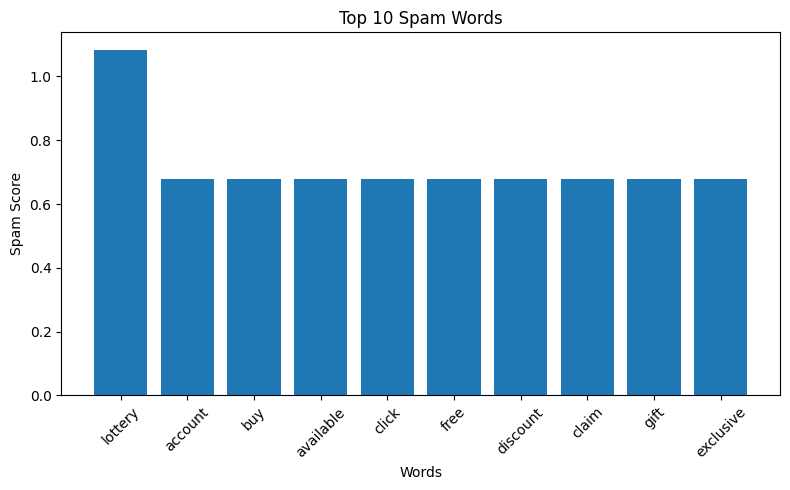

In [13]:

plt.figure(figsize=(8,5))
plt.bar(spam_df["Word"].head(10),
        spam_df["Score"].head(10))

plt.xticks(rotation=45)
plt.title("Top 10 Spam Words")
plt.xlabel("Words")
plt.ylabel("Spam Score")
plt.tight_layout()
plt.show()

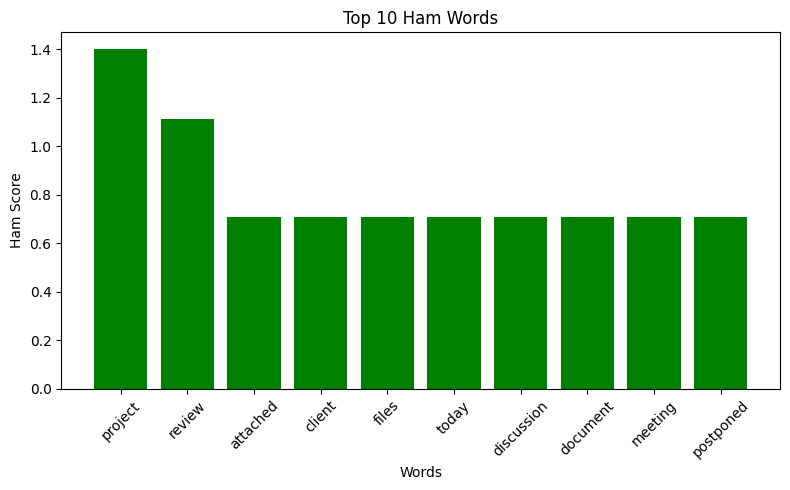

In [14]:
plt.figure(figsize=(8,5))
plt.bar(ham_df["Word"].head(10),
        ham_df["Score"].head(10),
        color="green")

plt.xticks(rotation=45)
plt.title("Top 10 Ham Words")
plt.xlabel("Words")
plt.ylabel("Ham Score")
plt.tight_layout()
plt.show()

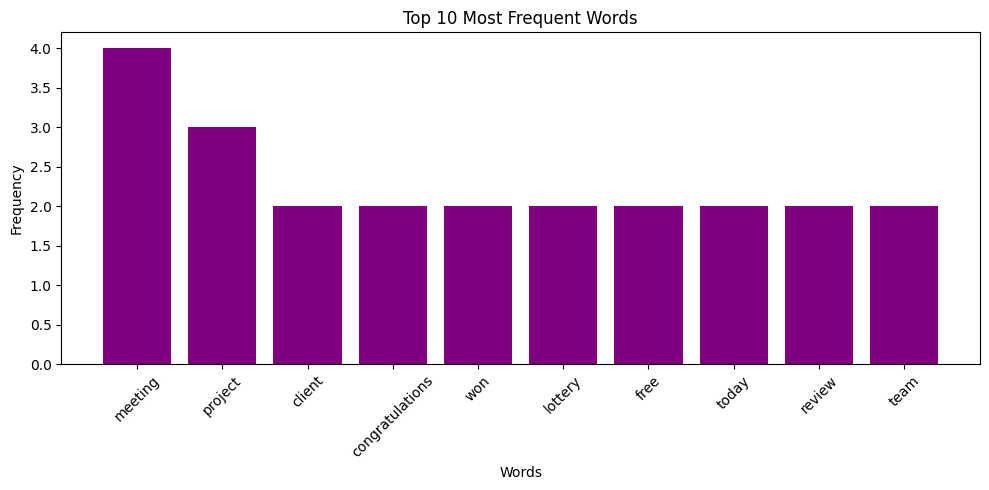

In [15]:
word_counts = X.toarray().sum(axis=0)

freq_df = pd.DataFrame({
    "Word": feature_names,
    "Frequency": word_counts
}).sort_values("Frequency", ascending=False)

plt.figure(figsize=(10,5))
plt.bar(freq_df["Word"].head(10),
        freq_df["Frequency"].head(10),
        color="purple")

plt.xticks(rotation=45)
plt.title("Top 10 Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


In [16]:
new_emails = [
    "Win a free vacation today",
    "Project meeting at 2 PM",
    "Claim your reward now",
    "Please submit the report",
    "Exclusive offer just for you"
]

new_vector = vectorizer.transform(new_emails)

prediction = model.predict(new_vector)

print("\nPrediction on New Emails\n")

for email, pred in zip(new_emails, prediction):
    print("--------------------------------")
    print("Email :", email)
    print("Prediction :", pred)


Prediction on New Emails

--------------------------------
Email : Win a free vacation today
Prediction : Spam
--------------------------------
Email : Project meeting at 2 PM
Prediction : Ham
--------------------------------
Email : Claim your reward now
Prediction : Spam
--------------------------------
Email : Please submit the report
Prediction : Ham
--------------------------------
Email : Exclusive offer just for you
Prediction : Spam
